***
# Homework 10: MapReduce in Python using `mrjob`

**Course:** STAT 606 - Computing in Data Science and Statistics SP24

**Name:** Shrivats Sudhir

**NetID:** ssudhir2

**Email:** ssudhir2@wisc.edu

**Collaborators:** Samuel Merten, Amy Merkelz

**Date:** April 21st, 2024
***

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## 1.) Warmup: counting words with mrjob (3 points, spent $\approx$ 10 minutes)

**In this problem, you’ll get a gentle introduction to `mrjob` on your machine locally. Then, we’ll run the same job on Google Cloud Platform on a larger data file.**

**Write an `mrjob` program that takes text as input and counts how many times each word occurs in the text. Your script should strip punctuation like full stops, commas  and semicolons, but you may treat hyphens, apostrophes, etc. as you wish. Simplest is to treat, e.g., “John’s” as two words, “John” and “s”, but feel free to do more complicated processing if you wish. Your script should ignore case, so that “Cat” and “cat” are considered the same word. Your output should be a collection of (word,count) pairs. Please save your script in a file called `mr_word_count.py` and include it in your submission.**

Problem completed and submitted as `mr_word_count.py`.

**Download this file and test your code on your local machine. The file is small enough that you should be able to check by hand whether your code is behaving correctly. Please include a copy of `simple.txt` in your submission. Save the output of running your script on this small file to a file called simple word `counts.txt` and include it in your submission**

Problem completed and submitted as `simple_word_counts.txt`. 

Given below is the windows powershell chunk that runs `mr_word_count.py` on `simple.txt`:

```powershell
PS C:\Users\shriv\OneDrive\Documents\ssudhir2_hw10> python mr_word_count.py simple.txt                                  
No configs found; falling back on auto-configuration
No configs specified for inline runner
Creating temp directory C:\Users\shriv\AppData\Local\Temp\mr_word_count.shriv.20240422.010818.930732
Running step 1 of 1...
job output is in C:\Users\shriv\AppData\Local\Temp\mr_word_count.shriv.20240422.010818.930732\output
Streaming final output from C:\Users\shriv\AppData\Local\Temp\mr_word_count.shriv.20240422.010818.930732\output...      
"and"   3
"cats"  3
"cheese"        1
"dogs"  2
"eat"   2
"fleas" 1
"have"  1
"mice"  3
"raining"       1
Removing temp directory C:\Users\shriv\AppData\Local\Temp\mr_word_count.shriv.20240422.010818.930732...
PS C:\Users\shriv\OneDrive\Documents\ssudhir2_hw10>
```

Given below is the output when `Get-content` and `Out-File` are ran in windows powershell to save output as `simple_word_counts.txt`:

```powershell
PS C:\Users\shriv\OneDrive\Documents\ssudhir2_hw10> Get-Content simple.txt | python mr_word_count.py | Out-File -FilePath simple_word_counts.txt
No configs found; falling back on auto-configuration
No configs specified for inline runner
Creating temp directory C:\Users\shriv\AppData\Local\Temp\mr_word_count.shriv.20240422.011209.700996
Running step 1 of 1...
reading from STDIN
job output is in C:\Users\shriv\AppData\Local\Temp\mr_word_count.shriv.20240422.011209.700996\output
Streaming final output from C:\Users\shriv\AppData\Local\Temp\mr_word_count.shriv.20240422.011209.700996\output...      
Removing temp directory C:\Users\shriv\AppData\Local\Temp\mr_word_count.shriv.20240422.011209.700996...
```

## 2.) Getting Set Up on Google Cloud Platform (3 points, spent $\approx$ 5 minutes)

**To run our MapReduce jobs on truly large data sets, we need to run in a distributed environment. That is, we need to run our job on multiple machines in parallel, instead of running only on our local machines. To do this, we will use Google Cloud Platform (GCP), Google’s distributed computing service. Google has provided us with a grant, which will provide everyone in the course with free compute time on GCP.**

**The first thing you should do is claim your share of the grant money. To do this, please follow the instructions from the announcement on Canvas, titled “Important: Claim Google Cloud Platform credits”, sent on March 21. When claiming your credits, please use the email address associated to your NetID (i.e., `NetID@wisc.edu`), so that we can easily determine which account belongs to which student. Failure to do so will result in a penalty. Once you have submitted the form to claim your credits, you will receive a confirmation email through which you can claim your compute credits. These credits are valid on GCP until they expire on January 24, 2025. Any credits left over after completing your coursework this semester are yours to use as you wish.**

**Note: Make sure that you claim your credits while signed in under your University of Wisconsin email, rather than a personal gmail account so that your project is correctly associated with your Wisconsin email. If you accidentally claim the credits under a different address, add your Wisconsin NetID email address as an owner (see below for further discussion of project ownership and roles on GCP).**

Completed the above procedure.

**Once you have claimed your credits, you should create a project, which will serve as a repository for your work on this problem. You should name your project `NetID-stat606s24`, where NetID is your UW NetID in all lower-case letters. Your project’s billing should be automatically linked to your credits, but you can verify this fact in the billing dashboard in the GCP browser console. Please add the instructor (NetID `kdlevin`) as well as your grader Jingyun Jia (NetID `jjia39`) as owners. You can do this in the IAM tab of the IAM & admin dashboard by clicking “Grant access” near the top of the page, listing our Wisconsin emails and specifying our Roles as Owner.**

Completed the above procedure.

## 3.) Running a simple mrjob program on GCP (8 points, spent $\approx$ 130 minutes)

**To check that you have everything set up properly, let’s try running your `mrjob` word counting program from Problem 1 on GCP.**

**The simplest way to transfer files to and from GCP (and store them on GCP) is using a *bucket*. This is the Google Cloud term for what is essentially a hard drive. Instructions on setting up a storage bucket can be found here:**

<h5 align="center"> https://cloud.google.com/storage/docs/creating-buckets </h5>

**Create a bucket named `NetID-stat606s24-hw10`, where NetID is your Wisconsin NetID in all lower-case letters. Make sure you set “Access control” to *Uniform*. You may set the remaining options (location, location type, storage class) as you see fit. The default values are all fine. Ignore the “Advanced settings”, and click the blue “Create” button. Once you have done all that, if you click the “Browser” button in the “Cloud Storage” menu on the left-hand sidebar, you should see your newly-created storage bucket listed.**


Completed the above procedure.

**Now it’s time to put some files in your new bucket. In the storage browser, click on the bucket you created in the previous part of this problem and click “Upload files”. Upload your mrjob program `mr_word_count.py` and the file `simple.txt` from the previous problem to your storage bucket. This is roughly analogous to moving a file from your local machine to a hard drive.**

***Note:* if you want a completely optional challenge (not worth any bonus points; just bragging rights), you can try using `wget` and the `gsutil` program in the Google Cloud shell to do this step, instead. In the blue bar at the top of your browser window in GCP, you should see an icon that looks like a terminal prompt. If you click that icon, a terminal will open at the bottom of your browser window. This is the Google Cloud shell, which supports basic UNIX/Linux command line programs like `wget`. You can use wget to download `simple.txt` from the course webpage, and then use the `gsutil` program to copy the file to your storage bucket. Type `gsutil` help in the Google Cloud shell to get started. If you’re feeling even more adventurous, you can try installing the gsutil tool on your own local machine to copy files to your storage bucket.**

Completed the above procedure. 

Given below is the Google CLoud SDK Shell Prompts to transfer `simple.txt` and `mr_word_count.py` from local directory to google cloud bucket by using installed version of `gsutil`:

```bash
C:\Users\shriv\AppData\Local\Google\Cloud SDK> gsutil cp C:\Users\shriv\OneDrive\Documents\ssudhir2_hw10\mr_word_count.p
y gs://ssudhir2-stat606s24-hw10/
Copying file://C:\Users\shriv\OneDrive\Documents\ssudhir2_hw10\mr_word_count.py [Content-Type=text/x-python]...
- [1 files][  2.6 KiB/  2.6 KiB]
Operation completed over 1 objects/2.6 KiB.

C:\Users\shriv\AppData\Local\Google\Cloud SDK> gsutil cp C:\Users\shriv\OneDrive\Documents\ssudhir2_hw10\simple.txt gs://ssudhir2-stat606s24-hw10/
Copying file://C:\Users\shriv\OneDrive\Documents\ssudhir2_hw10\simple.txt [Content-Type=text/plain]...
- [1 files][   87.0 B/   87.0 B]
Operation completed over 1 objects/87.0 B.

C:\Users\shriv\AppData\Local\Google\Cloud SDK> gsutil ls gs://ssudhir2-stat606s24-hw10
gs://ssudhir2-stat606s24-hw10/README-cloudshell.txt
gs://ssudhir2-stat606s24-hw10/mr_word_count.py
gs://ssudhir2-stat606s24-hw10/simple.txt
```

**Now let’s try running `mr_word_count.py` on `simple.txt`, this time on GCP. Open the Cloud shell (click the icon that looks like a terminal prompt in the blue bar near the top of your browser window) and type gsutil ls. If your storage bucket is set up correctly, you should see its name displayed in the output as `gs://NetID-stat606s24-hw10`, where NetID is your NetID. Copy `mr_word_count.py` from your storage bucket to your local shell environment by typing**

<h5 align="center"> gsutil cp gs://NetID-stat606s24-hw10/mr_word_count.py .</h5>

Transferring both `simple.txt` and `mr_word_count.py` to current instance:

```bash
ssudhir2@cloudshell:~ (ssudhir2-stat606s24)$ gsutil cp gs://ssudhir2-stat606s24-hw10/simple.txt .
Copying gs://ssudhir2-stat606s24-hw10/simple.txt...
/ [1 files][   87.0 B/   87.0 B]                                                
Operation completed over 1 objects/87.0 B.                                       
ssudhir2@cloudshell:~ (ssudhir2-stat606s24)$ gsutil cp gs://ssudhir2-stat606s24-hw10/mr_word_count.py .
Copying gs://ssudhir2-stat606s24-hw10/mr_word_count.py...
/ [1 files][  2.2 KiB/  2.2 KiB]                                                
Operation completed over 1 objects/2.2 KiB.                                      
ssudhir2@cloudshell:~ (ssudhir2-stat606s24)$ ls
mr_word_count.py  README-cloudshell.txt  simple.txt
```

**at the command prompt. If all went well, you should see some output about copying your file and a message saying “Operation completed over 1 objects...”. Use a similar command to copy `simple.txt` from your storage bucket to the shell session. Type `ls` and you should see both `mr_word_count.py` and `simple.txt` as being among your local files. Now, you should be able to run your `mrjob` program just like you did in Problem 1 by typing in the cloud shell.**

<h5 align="center"> python2 mr_word_count.py simple.txt </h5>

```bash
ssudhir2@cloudshell:~ (ssudhir2-stat606s24)$ python2 mr_word_count.py simple.txt
No configs found; falling back on auto-configuration
No configs specified for inline runner
Creating temp directory /tmp/mr_word_count.ssudhir2.20240422.032027.862939
Running step 1 of 1...
job output is in /tmp/mr_word_count.ssudhir2.20240422.032027.862939/output
Streaming final output from /tmp/mr_word_count.ssudhir2.20240422.032027.862939/output...
"eat"   2
"fleas" 1
"raining"       1
"cheese"        1
"dogs"  2
"have"  1
"mice"  3
"cats"  3
"and"   3
Removing temp directory /tmp/mr_word_count.ssudhir2.20240422.032027.862939...
```

**Use a redirect to store the output of this in a file called `shell.simple.out`, and use `gsutil cp` to copy this output file back to your storage bucket. Once you have done this, you should be able to see `shell.simple.out` as listed among the files in your bucket.**

```bash
ssudhir2@cloudshell:~ (ssudhir2-stat606s24)$ cat simple.txt | python2 mr_word_count.py > shell.simple.out    
No configs found; falling back on auto-configuration
No configs specified for inline runner
Creating temp directory /tmp/mr_word_count.ssudhir2.20240422.033312.374594
Running step 1 of 1...
reading from STDIN
job output is in /tmp/mr_word_count.ssudhir2.20240422.033312.374594/output
Streaming final output from /tmp/mr_word_count.ssudhir2.20240422.033312.374594/output...
Removing temp directory /tmp/mr_word_count.ssudhir2.20240422.033312.374594...
ssudhir2@cloudshell:~ (ssudhir2-stat606s24)$ ls
mr_word_count.py  README-cloudshell.txt  shell.simple.out  simple.txt
ssudhir2@cloudshell:~ (ssudhir2-stat606s24)$ gsutil cp shell.simple.out gs://ssudhir2-stat606s24-hw10/
Copying file://shell.simple.out [Content-Type=application/octet-stream]...
/ [1 files][   85.0 B/   85.0 B]                                                
Operation completed over 1 objects/85.0 B.                                       
```

**Okay, now things can start getting interesting. The whole point of using a service like GCP is that it gives us convenient access to cluster computing resources. So let’s use GCP to run our `mrjob` program on a proper Hadoop cluster. On GCP, Dataproc provides Apache Hadoop and related services. The `mrjob` documentation includes some instructions for running your `mrjob` program on Dataproc:**

<h5 align="center"> https://mrjob.readthedocs.io/en/latest/guides/dataproc-quickstart.html#running-a-dataproc-job </h5>

**You can try to run the example given there, adapted to our setting, by typing**

<h5 align="center"> python2 mr_word_count.py -r dataproc README-cloudshell.txt </h5>

**his may result in an error message (from Python, not from gsutil) that you must install `google-cloud-logging`, `google-cloud-storage` or both in order to connect to Dataproc. If you get a message along these lines, try running**

<h5 align="center"> pip2 install mrjob google-cloud-dataproc google-cloud-logging google-cloud-storage </h5>

**to make sure that the Python installation running in your GCP shell has the requisite packages for interacting with the rest of GCP. Another common error is a Python error with the message**

<h5 align="center"> TypeError: __init__() got an unexpected keyword argument ’channel’. </h5>

**This is caused by the fact that the `detok-cloud-dataproc` library in Python changed in 2022, and `mrjob` was not updated accordingly. You can solve this by calling**

<h5 align="center"> pip2 install --force-reinstall --no-deps google-cloud-dataproc==1.1.1 </h5>

**in the Google Cloud shell to revert the Python google-cloud-dataproc package to the earlier version that mrjob is expecting. If you are still getting errors after trying these two corrections, make a post in the discussion board, because it is almost certainly the case that your classmates are encountering a similar error.**

**Note: Part of my goal in having you do all this is for you to see the kinds of annoying and/or weird errors that are typical when we start trying to use multiple interacting tools, each of which is frequently being updated, often with API-breaking changes. If you don’t like the idea of spending hours chasing down and solving these kinds of weird bugs, I suggest you find another line of work!**

**When you successfully run an mrjob program, you’ll see output along the lines of**

```
No configs found; falling back on auto-configuration
No configs specified for dataproc runner
using existing temp bucket mrjob-[REGION]-[alphanumerics]
```

**Followed by some logging information about creating temporary directories and “waiting for cluster to accept jobs”. You will likely need to wait five or ten minutes for your job to finish running– a lot longer than running on your local machine. This is because GCP needs time to set up machines to serve as the nodes in your cluster before it can actually run your job. Essentially, GCP is recruiting a collection of machines for you to use temporarily as your compute cluster and installing the necessary software on those machines for them to be nodes in a Hadoop cluster, and only then is it running your job on that Hadoop cluster. This is an example of what are sometimes called startup costs in distributed computing. If we have a large job to run, having a lot of computers on which to run it in parallel should make things faster, but there is an up-front cost to pay in the time it takes to “spin up” all those computers, as well as teardown costs once our job is finished running and GCP has to terminate all those worker nodes and free up the computing resources for other users.**

Given below is the script that `-r dataproc` to run `mr_word_count.py` with input text as `README-cloudshell.txt`:

```bash
ssudhir2@cloudshell:~ (ssudhir2-stat606s24)$ python3 mr_word_count.py -r dataproc README-cloudshell.txt                                                                                               
No configs found; falling back on auto-configuration
No configs specified for dataproc runner
Creating temp directory /tmp/mr_word_count.ssudhir2.20240423.200720.361007
writing master bootstrap script to /tmp/mr_word_count.ssudhir2.20240423.200720.361007/b.sh
uploading working dir files to gs://mrjob-us-west1-66d73b30f34764e4/tmp/mr_word_count.ssudhir2.20240423.200720.361007/files/wd...
Copying other local files to gs://mrjob-us-west1-66d73b30f34764e4/tmp/mr_word_count.ssudhir2.20240423.200720.361007/files/
Waiting for GCS sync (eventual consistency) - sleeping 5.0 second(s)
Creating Dataproc Hadoop cluster - mrjob-us-west1-d4df18c31ef11dab
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Submitting Dataproc Hadoop Job - mr_word_count-ssudhir2-20240423-200720-361007---step-00001-of-00001
Submitted Dataproc Hadoop Job - mr_word_count-ssudhir2-20240423-200720-361007---step-00001-of-00001
mr_word_count-ssudhir2-20240423-200720-361007---step-00001-of-00001 => SETUP_DONE
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-200720-361007---step-00001-of-00001 => SETUP_DONE
  Parsing job driver output from gs://dataproc-staging-us-west1-89254757867-an4imqwl/google-cloud-dataproc-metainfo/d19878db-0b68-4c3c-ae0a-a6f6cd898e48/jobs/mr_word_count-ssudhir2-20240423-200720-361007---step-00001-of-00001/driveroutput*
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-200720-361007---step-00001-of-00001 => SETUP_DONE
  map 0% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-200720-361007---step-00001-of-00001 => RUNNING
  map 0% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-200720-361007---step-00001-of-00001 => RUNNING
  map 13% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-200720-361007---step-00001-of-00001 => RUNNING
  map 44% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-200720-361007---step-00001-of-00001 => RUNNING
  map 56% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-200720-361007---step-00001-of-00001 => RUNNING
  map 88% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-200720-361007---step-00001-of-00001 => RUNNING
  map 100% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-200720-361007---step-00001-of-00001 => DONE
  map 100% reduce 100%
Counters: 55
        File Input Format Counters 
                Bytes Read=7408
        File Output Format Counters 
                Bytes Written=962
        File System Counters
                FILE: Number of bytes read=1679
                FILE: Number of bytes written=3833048
                FILE: Number of large read operations=0
                FILE: Number of read operations=0
                FILE: Number of write operations=0
                GS: Number of bytes read=7408
                GS: Number of bytes written=962
                GS: Number of large read operations=0
                GS: Number of read operations=0
                GS: Number of write operations=0
                HDFS: Number of bytes read=2656
                HDFS: Number of bytes written=0
                HDFS: Number of large read operations=0
                HDFS: Number of read operations=16
                HDFS: Number of write operations=0
        Job Counters 
                Killed map tasks=1
                Launched map tasks=16
                Launched reduce tasks=2
                Rack-local map tasks=16
                Total megabyte-milliseconds taken by all map tasks=250049536
                Total megabyte-milliseconds taken by all reduce tasks=41123840
                Total time spent by all map tasks (ms)=244189
                Total time spent by all maps in occupied slots (ms)=976756
                Total time spent by all reduce tasks (ms)=20080
                Total time spent by all reduces in occupied slots (ms)=160640
                Total vcore-milliseconds taken by all map tasks=244189
                Total vcore-milliseconds taken by all reduce tasks=20080
        Map-Reduce Framework
                CPU time spent (ms)=14370
                Combine input records=0
                Combine output records=0
                Failed Shuffles=0
                GC time elapsed (ms)=4751
                Input split bytes=2656
                Map input records=16
                Map output bytes=1397
                Map output materialized bytes=1859
                Map output records=135
                Merged Map outputs=32
                Physical memory (bytes) snapshot=7478501376
                Reduce input groups=86
                Reduce input records=135
                Reduce output records=86
                Reduce shuffle bytes=1859
                Shuffled Maps =32
                Spilled Records=270
                Total committed heap usage (bytes)=5488582656
                Virtual memory (bytes) snapshot=47181832192
        Shuffle Errors
                BAD_ID=0
                CONNECTION=0
                IO_ERROR=0
                WRONG_LENGTH=0
                WRONG_MAP=0
                WRONG_REDUCE=0
Completed Dataproc Hadoop Job - mr_word_count-ssudhir2-20240423-200720-361007---step-00001-of-00001
Waiting for GCS sync (eventual consistency) - sleeping 5.0 second(s)
job output is in gs://mrjob-us-west1-66d73b30f34764e4/tmp/mr_word_count.ssudhir2.20240423.200720.361007/output/
Streaming final output from gs://mrjob-us-west1-66d73b30f34764e4/tmp/mr_word_count.ssudhir2.20240423.200720.361007/output/...
"a"     2
"across"        1
"aliased"       1
"and"   3
"approximately" 1
"at"    1
"be"    1
"beyond"        1
"builtin"       1
"but"   1
"cloud" 4
"cloudshell"    3
"comes" 1
"common"        1
"directory"     1
"ephemeral"     1
"examples"      1
"filename"      1
"for"   3
"functionality" 1
"google"        3
"help"  7
"home"  1
"hosted"        1
"in"    1
"machine"       1
"message"       1
"minutes"       1
"more"  1
"no"    1
"on"    3
"platform"      1
"popular"       1
"preinstalled"  1
"reset" 1
"resources"     1
"see"   3
"sessions"      1
"that"  1
"the"   4
"these" 1
"time"  1
"to"    8
"tools" 1
"visit" 1
"vm"    1
"you"   1
"your"  3
"20"    1
"5gb"   1
"after" 1
"aliases"       1
"any"   1
"bash"  2
"can"   1
"change"        1
"commands"      2
"developer"     1
"dl"    1
"download"      1
"ends"  1
"example"       1
"file"  1
"gcloud"        1
"get"   2
"httpscloudgooglecomshelldocsexamples"  1
"httpscloudgooglecomshelldocsquickstart"        1
"interpreter"   1
"is"    2
"managing"      1
"other" 1
"persist"       2
"prompt"        1
"sdk"   2
"session"       1
"shell" 2
"short" 1
"systemwide"    1
"this"  1
"tool"  1
"type"  6
"using" 2
"utility"       1
"welcome"       1
"will"  3
"with"  1
Removing temp directory /tmp/mr_word_count.ssudhir2.20240423.200720.361007...
Attempting to terminate cluster
cluster mrjob-us-west1-d4df18c31ef11dab successfully terminated
```

**Once your job finishes running, you should see the output of your program, followed by a bit more logging information. If everything looks correct, run your Hadoop word count script `mr_word_count.py` on `simple.txt` again, this time using the Dataproc cluster instead of running locally. Use a redirect to send the stdout output (i.e., the word counts) to a file called `hadoop.simple.out`, and send stderr (i.e., the logging information) to a file called `hadoop.simple.log`. Use `gsutil` to copy these files to your storage bucket. You will notice that GCP created a few temporary storage buckets when it created your Hadoop cluster. These contain some logging information about creating and running your Hadoop cluster. You are welcome to delete these once your job is finished. Just be careful not to delete your `NetID-stat606s24-hw10` bucket.**

Given below is the script that utilizes `-r dataproc` to run `mr_word_count.py` with input text as `simple.txt`:

```bash
ssudhir2@cloudshell:~ (ssudhir2-stat606s24)$ python3 mr_word_count.py -r dataproc simple.txt                                                                                                          
No configs found; falling back on auto-configuration
No configs specified for dataproc runner
using existing temp bucket mrjob-us-west1-66d73b30f34764e4
Creating temp directory /tmp/mr_word_count.ssudhir2.20240423.201453.172769
writing master bootstrap script to /tmp/mr_word_count.ssudhir2.20240423.201453.172769/b.sh
uploading working dir files to gs://mrjob-us-west1-66d73b30f34764e4/tmp/mr_word_count.ssudhir2.20240423.201453.172769/files/wd...
Copying other local files to gs://mrjob-us-west1-66d73b30f34764e4/tmp/mr_word_count.ssudhir2.20240423.201453.172769/files/
Waiting for GCS sync (eventual consistency) - sleeping 5.0 second(s)
Creating Dataproc Hadoop cluster - mrjob-us-west1-7c80a7f43bacf038
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Submitting Dataproc Hadoop Job - mr_word_count-ssudhir2-20240423-201453-172769---step-00001-of-00001
Submitted Dataproc Hadoop Job - mr_word_count-ssudhir2-20240423-201453-172769---step-00001-of-00001
mr_word_count-ssudhir2-20240423-201453-172769---step-00001-of-00001 => SETUP_DONE
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-201453-172769---step-00001-of-00001 => SETUP_DONE
  Parsing job driver output from gs://dataproc-staging-us-west1-89254757867-an4imqwl/google-cloud-dataproc-metainfo/2b32b931-4f65-4f6e-831f-52096d186428/jobs/mr_word_count-ssudhir2-20240423-201453-172769---step-00001-of-00001/driveroutput*
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-201453-172769---step-00001-of-00001 => SETUP_DONE
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-201453-172769---step-00001-of-00001 => RUNNING
  map 0% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-201453-172769---step-00001-of-00001 => RUNNING
  map 0% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-201453-172769---step-00001-of-00001 => RUNNING
  map 28% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-201453-172769---step-00001-of-00001 => RUNNING
  map 39% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-201453-172769---step-00001-of-00001 => RUNNING
  map 67% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-201453-172769---step-00001-of-00001 => RUNNING
  map 67% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-201453-172769---step-00001-of-00001 => RUNNING
  map 100% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-201453-172769---step-00001-of-00001 => RUNNING
  map 100% reduce 50%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240423-201453-172769---step-00001-of-00001 => DONE
  map 100% reduce 100%
Counters: 55
        File Input Format Counters 
                Bytes Read=801
        File Output Format Counters 
                Bytes Written=85
        File System Counters
                FILE: Number of bytes read=200
                FILE: Number of bytes written=4255414
                FILE: Number of large read operations=0
                FILE: Number of read operations=0
                FILE: Number of write operations=0
                GS: Number of bytes read=801
                GS: Number of bytes written=85
                GS: Number of large read operations=0
                GS: Number of read operations=0
                GS: Number of write operations=0
                HDFS: Number of bytes read=2790
                HDFS: Number of bytes written=0
                HDFS: Number of large read operations=0
                HDFS: Number of read operations=18
                HDFS: Number of write operations=0
        Job Counters 
                Killed map tasks=1
                Launched map tasks=18
                Launched reduce tasks=2
                Rack-local map tasks=18
                Total megabyte-milliseconds taken by all map tasks=282576896
                Total megabyte-milliseconds taken by all reduce tasks=41598976
                Total time spent by all map tasks (ms)=275954
                Total time spent by all maps in occupied slots (ms)=1103816
                Total time spent by all reduce tasks (ms)=20312
                Total time spent by all reduces in occupied slots (ms)=162496
                Total vcore-milliseconds taken by all map tasks=275954
                Total vcore-milliseconds taken by all reduce tasks=20312
        Map-Reduce Framework
                CPU time spent (ms)=15750
                Combine input records=0
                Combine output records=0
                Failed Shuffles=0
                GC time elapsed (ms)=4622
                Input split bytes=2790
                Map input records=3
                Map output bytes=154
                Map output materialized bytes=404
                Map output records=17
                Merged Map outputs=36
                Physical memory (bytes) snapshot=8281182208
                Reduce input groups=9
                Reduce input records=17
                Reduce output records=9
                Reduce shuffle bytes=404
                Shuffled Maps =36
                Spilled Records=34
                Total committed heap usage (bytes)=6143164416
                Virtual memory (bytes) snapshot=52235673600
        Shuffle Errors
                BAD_ID=0
                CONNECTION=0
                IO_ERROR=0
                WRONG_LENGTH=0
                WRONG_MAP=0
                WRONG_REDUCE=0
Completed Dataproc Hadoop Job - mr_word_count-ssudhir2-20240423-201453-172769---step-00001-of-00001
Waiting for GCS sync (eventual consistency) - sleeping 5.0 second(s)
job output is in gs://mrjob-us-west1-66d73b30f34764e4/tmp/mr_word_count.ssudhir2.20240423.201453.172769/output/
Streaming final output from gs://mrjob-us-west1-66d73b30f34764e4/tmp/mr_word_count.ssudhir2.20240423.201453.172769/output/...
"and"   3
"cats"  3
"cheese"        1
"dogs"  2
"fleas" 1
"eat"   2
"have"  1
"mice"  3
"raining"       1
Removing temp directory /tmp/mr_word_count.ssudhir2.20240423.201453.172769...
Attempting to terminate cluster
cluster mrjob-us-west1-7c80a7f43bacf038 successfully terminated
```

Completed the above procedure and submitted it as `hadoop.simple.out` and `hadoop.simple.log`.

**I have made a larger file available publicly (okay, actually, it’s still not really large enough to warrant using distributed computing, but large enough to be good practice). In the Cloud shell, try typing `gsutil ls gs://uw-stat606s24-hw10` The output should include a file called `darwin.txt`. This is a slight modification of the Project Gutenberg plain text version of Charles Darwin’s famous On the Origin of Species. To run your script on a file stored on a storage bucket, you can call `python2 mr_word_count.py -r dataproc gs://uw-stat606s24-hw10/darwin.txt` Run your script on this file, save its output in a file called `darwin_word_counts.txt`, and copy this file to your storage bucket. You should also download a copy of your output and include it in your submission.**

Completed the above procedure and submitted it as `darwin_word_counts.txt`.

Given below is the script that uses `-r dataproc` to run `mr_word_count.py` with input text as `darwin.txt`, and saved as `darwin_word_counts.txt`:

```bash
ssudhir2@cloudshell:~ (ssudhir2-stat606s24)$ python3 mr_word_count.py -r dataproc darwin.txt 1> darwin_word_counts.txt
No configs found; falling back on auto-configuration
No configs specified for dataproc runner
Creating temp directory /tmp/mr_word_count.ssudhir2.20240424.020617.468514
writing master bootstrap script to /tmp/mr_word_count.ssudhir2.20240424.020617.468514/b.sh
uploading working dir files to gs://mrjob-us-west1-9ff30ac8ae378de4/tmp/mr_word_count.ssudhir2.20240424.020617.468514/files/wd...
Copying other local files to gs://mrjob-us-west1-9ff30ac8ae378de4/tmp/mr_word_count.ssudhir2.20240424.020617.468514/files/
Waiting for GCS sync (eventual consistency) - sleeping 5.0 second(s)
Creating Dataproc Hadoop cluster - mrjob-us-west1-6816bf2feb45551a
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Submitting Dataproc Hadoop Job - mr_word_count-ssudhir2-20240424-020617-468514---step-00001-of-00001
Submitted Dataproc Hadoop Job - mr_word_count-ssudhir2-20240424-020617-468514---step-00001-of-00001
mr_word_count-ssudhir2-20240424-020617-468514---step-00001-of-00001 => SETUP_DONE
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240424-020617-468514---step-00001-of-00001 => SETUP_DONE
  Parsing job driver output from gs://dataproc-staging-us-west1-89254757867-an4imqwl/google-cloud-dataproc-metainfo/7d1abaf6-2b41-4b89-8ce6-af7331eb9ac8/jobs/mr_word_count-ssudhir2-20240424-020617-468514---step-00001-of-00001/driveroutput*
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240424-020617-468514---step-00001-of-00001 => SETUP_DONE
  map 0% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240424-020617-468514---step-00001-of-00001 => SETUP_DONE
  map 0% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240424-020617-468514---step-00001-of-00001 => RUNNING
  map 13% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240424-020617-468514---step-00001-of-00001 => RUNNING
  map 47% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240424-020617-468514---step-00001-of-00001 => RUNNING
  map 60% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240424-020617-468514---step-00001-of-00001 => RUNNING
  map 80% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240424-020617-468514---step-00001-of-00001 => RUNNING
  map 100% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240424-020617-468514---step-00001-of-00001 => RUNNING
  map 100% reduce 100%
Waiting for job completion - sleeping 10.0 second(s)
mr_word_count-ssudhir2-20240424-020617-468514---step-00001-of-00001 => DONE
  map 100% reduce 100%
Counters: 55
        File Input Format Counters 
                Bytes Read=1017449
        File Output Format Counters 
                Bytes Written=105934
        File System Counters
                FILE: Number of bytes read=1857218
                FILE: Number of bytes written=7331184
                FILE: Number of large read operations=0
                FILE: Number of read operations=0
                FILE: Number of write operations=0
                GS: Number of bytes read=1017449
                GS: Number of bytes written=105934
                GS: Number of large read operations=0
                GS: Number of read operations=0
                GS: Number of write operations=0
                HDFS: Number of bytes read=2325
                HDFS: Number of bytes written=0
                HDFS: Number of large read operations=0
                HDFS: Number of read operations=15
                HDFS: Number of write operations=0
        Job Counters 
                Killed map tasks=1
                Launched map tasks=15
                Launched reduce tasks=2
                Rack-local map tasks=15
                Total megabyte-milliseconds taken by all map tasks=258288640
                Total megabyte-milliseconds taken by all reduce tasks=49858560
                Total time spent by all map tasks (ms)=252235
                Total time spent by all maps in occupied slots (ms)=1008940
                Total time spent by all reduce tasks (ms)=24345
                Total time spent by all reduces in occupied slots (ms)=194760
                Total vcore-milliseconds taken by all map tasks=252235
                Total vcore-milliseconds taken by all reduce tasks=24345
        Map-Reduce Framework
                CPU time spent (ms)=18000
                Combine input records=0
                Combine output records=0
                Failed Shuffles=0
                GC time elapsed (ms)=4529
                Input split bytes=2325
                Map input records=14891
                Map output bytes=1543292
                Map output materialized bytes=1857386
                Map output records=156957
                Merged Map outputs=30
                Physical memory (bytes) snapshot=7011082240
                Reduce input groups=8280
                Reduce input records=156957
                Reduce output records=8280
                Reduce shuffle bytes=1857386
                Shuffled Maps =30
                Spilled Records=313914
                Total committed heap usage (bytes)=5161291776
                Virtual memory (bytes) snapshot=44658290688
        Shuffle Errors
                BAD_ID=0
                CONNECTION=0
                IO_ERROR=0
                WRONG_LENGTH=0
                WRONG_MAP=0
                WRONG_REDUCE=0
Completed Dataproc Hadoop Job - mr_word_count-ssudhir2-20240424-020617-468514---step-00001-of-00001
Waiting for GCS sync (eventual consistency) - sleeping 5.0 second(s)
job output is in gs://mrjob-us-west1-9ff30ac8ae378de4/tmp/mr_word_count.ssudhir2.20240424.020617.468514/output/
Streaming final output from gs://mrjob-us-west1-9ff30ac8ae378de4/tmp/mr_word_count.ssudhir2.20240424.020617.468514/output/...
Removing temp directory /tmp/mr_word_count.ssudhir2.20240424.020617.468514...
Attempting to terminate cluster
cluster mrjob-us-west1-6816bf2feb45551a successfully terminated
```

**Zipf’s law states that if one plots word frequency against frequency rank (i.e., most frequent word, second most frequent word, etc.), the resulting line is (approximately) linear on a log-log scale. Using the information in `darwin_word_counts.txt`, make a plot of word frequency as a function of word rank on a log-log scale for all words in the file `darwin.txt`. Give an appropriate title to your plot and include axis labels. Save the plot as a pdf file called `zipf.pdf`, and include it in your submission.**

In [3]:
df = pd.read_csv('darwin_word_counts.txt', sep = "\t", header = None, on_bad_lines='skip', names = ['Names', 'Count']).sort_values(by = 'Count', ascending = False).reset_index(drop = True)
df['Rank'] = df.index + 1
df

,Names,Count,Rank
0,the,10310,1
1,of,7899,2
2,and,4436,3
3,in,4022,4
4,to,3621,5
...,...,...,...
8272,wanted,1,8273
8273,wardance,1,8274
8274,warmestclad,1,8275
8275,warned,1,8276


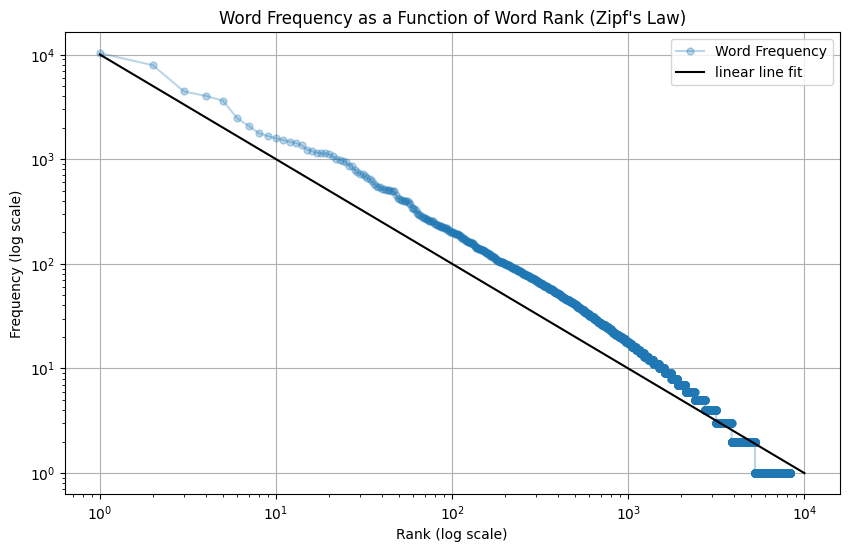

In [4]:
# Log-log plot of frequency vs rank
plt.figure(figsize=(10, 6))

plt.loglog(df['Rank'], 
           df['Count'], 
           marker = 'o',
           alpha = 0.3, 
           markersize = 5, 
           label = 'Word Frequency')

# Calculate the coefficients of the line (log-log space)
m, b = np.polyfit(np.log(np.array([1, 10**4])), np.log(np.array([10**4, 1])), 1)

plt.loglog(np.logspace(0, 4, 400), np.exp(m * np.log(np.logspace(0, 4, 400)) + b), 'black', label=f'linear line fit')

plt.title('Word Frequency as a Function of Word Rank (Zipf\'s Law)')
plt.xlabel('Rank (log scale)')
plt.ylabel('Frequency (log scale)')
plt.legend()
plt.grid(True)

plt.savefig('zipf.pdf')
plt.show()

**How “Zipfian” does the resulting plot look (It suffices for you to state whether or not your plot looks approximately like a line)?**

Fitting the Freqency vs Rank (Log Scaled) plot, overlayed with a straight (logarithmically speaking) line, we can see that our plot looks pretty linear for the most part.

## 4.) Computing Sample Statistics with `mrjob` (6 points, spent $\approx$ 45 minutes)

**In this problem, we’ll compile some basic statistics summarizing a toy dataset. The file**

<h5 align="center"> https://pages.stat.wisc.edu/~kdlevin/teaching/Spring2024/STAT606/populations_small.txt </h5>

**contains a collection of (class,value) pairs, one per line, with each line taking the form `class_label value`, where `class_label` is a non-negative integer and value is a float. Each pair corresponds to an observation, with the class labels corresponding to different populations, and the values corresponding to some measured quantity.**

**Write an `mrjob` program called `mr_summary_stats.py` that takes as input a sequence of (label,value) pairs like in the file `populations_small.txt`, and outputs a collection of 4-tuples of the form (label, number of samples, mean, variance), in which one 4-tuple appears for each class label in the data, and the mean and variance are the sample mean and variance, respectively, of all the values for that class label.** 

**Thus, if 25 unique class labels are present in the input then your program should output 25 lines, one for each class label. Please include a copy of `mr_summary_stats.py` in your submission.** 

**Note: you may use either $n$ or $n − 1$ in the denominator of your sample variance formula—just be clear which one you are using.** 

**Note: you don’t need to do any special formatting of the output. That is, your output is fine if it consists of lines of the form label `[number,mean,variance]` or similar.**

**Hint: Think carefully about what your key-value pairs should be here, as well as what your mappers, reducers, etc. should be. Should there be more than one step in your job? Sit down with pen and paper first!**

**Second hint: to compute the sample mean and sample variance of a collection of numbers, it suffices to know their sum, the sum of their squares, and the size of the collection.**

I chose to use the unbiased estimator version of sample variance, i.e.,
$$
\text{Sample Variance} = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n-1}
$$
where $\bar{x}$ is the sample mean, i.e.,
$$
\bar{x} = \frac{\sum_{i=1}^{n}x_i}{n}
$$

Completed the above procedure and submitted it as `mr_summary_stats.py`.

**On your local machine (i.e., not on Google Cloud), run your mrjob script on the `populations_small.txt` file and write the output to a file called `summary_small.txt`. Include this output file as well as a copy of `populations_small.txt` in your submission. Inspect your program’s output and verify that it is behaving as expected, noting that the small file is small enough that you should be able to check by hand what the results should be.**

Given below is the script that runs `mr_summary_stats.py` with input text as `populations_small.txt`, and saved the output as `summary_small.txt`:

```powershell
PS C:\Users\shriv\OneDrive\Documents\ssudhir2_hw10> Get-Content populations_small.txt | python mr_summary_stats.py | Out-File -FilePath summary_small.txt  
No configs found; falling back on auto-configuration
No configs specified for inline runner
Creating temp directory C:\Users\shriv\AppData\Local\Temp\mr_summary_stats.shriv.20240424.170157.127145    
Running step 1 of 1...
reading from STDIN
job output is in C:\Users\shriv\AppData\Local\Temp\mr_summary_stats.shriv.20240424.170157.127145\output
Streaming final output from C:\Users\shriv\AppData\Local\Temp\mr_summary_stats.shriv.20240424.170157.127145\output...
Removing temp directory C:\Users\shriv\AppData\Local\Temp\mr_summary_stats.shriv.20240424.170157.127145... 
```

**I have uploaded a much larger data file to GCP, available at**

<h5 align="center"> gs://uw-stat606s24-hw10/populations_large.txt . </h5>

**Once you are sure that your script is doing what you want on the small file, run it on this larger file. Don’t forget to use the `-r dataproc` flag to tell mrjob to run on a Hadoop server rather than in the Cloud shell. Save the output in a file called `summary_large.txt`. Copy this file to your storage bucket, and download a copy to include in your submission.**

Transferring `mr_summary_stats.py` from local to cloud storage using google cloud SDK shell:

```powershell
C:\Users\shriv\AppData\Local\Google\Cloud SDK> gsutil cp C:\Users\shriv\OneDrive\Documents\ssudhir2_hw10\mr_summary_stat
s.py gs://ssudhir2-stat606s24-hw10
Copying file://C:\Users\shriv\OneDrive\Documents\ssudhir2_hw10\mr_summary_stats.py [Content-Type=text/x-python]...
- [1 files][  2.1 KiB/  2.1 KiB]
Operation completed over 1 objects/2.1 KiB.
```

Transferring `mr_summary_stats.py` from cloud storage to console terminal instance:
```bash
ssudhir2@cloudshell:~ (ssudhir2-stat606s24)$ gsutil cp gs://ssudhir2-stat606s24-hw10/mr_summary_stats.py .
Copying gs://ssudhir2-stat606s24-hw10/mr_summary_stats.py...
/ [1 files][  2.1 KiB/  2.1 KiB]                                                
Operation completed over 1 objects/2.1 KiB.                                      
```

Transferring `populations_large.txt` from `gs://uw-stat606s24-hw10` to console terminal instance:
```bash
ssudhir2@cloudshell:~ (ssudhir2-stat606s24)$ gsutil cp gs://uw-stat606s24-hw10/populations_large.txt .
Copying gs://uw-stat606s24-hw10/populations_large.txt...
\ [1 files][138.4 MiB/138.4 MiB]                                                
Operation completed over 1 objects/138.4 MiB.                                  
```

Given below is the script that uses `-r dataproc` to run `mr_summary_stats.py` with input text as `populations_large.txt`, and saved as `populations_large.txt`:

```bash
ssudhir2@cloudshell:~ (ssudhir2-stat606s24)$ python3 mr_summary_stats.py -r dataproc populations_large.txt 1> summary_large.txt
No configs found; falling back on auto-configuration
No configs specified for dataproc runner
Creating temp directory /tmp/mr_summary_stats.ssudhir2.20240424.170711.706318
writing master bootstrap script to /tmp/mr_summary_stats.ssudhir2.20240424.170711.706318/b.sh
uploading working dir files to gs://mrjob-us-west1-52363277ecc743cf/tmp/mr_summary_stats.ssudhir2.20240424.170711.706318/files/wd...
Copying other local files to gs://mrjob-us-west1-52363277ecc743cf/tmp/mr_summary_stats.ssudhir2.20240424.170711.706318/files/
Waiting for GCS sync (eventual consistency) - sleeping 5.0 second(s)
Creating Dataproc Hadoop cluster - mrjob-us-west1-d33a2fc25bba7a6c
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Waiting for cluster to accept jobs - sleeping 10.0 second(s)
Submitting Dataproc Hadoop Job - mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001
Submitted Dataproc Hadoop Job - mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => SETUP_DONE
Waiting for job completion - sleeping 10.0 second(s)
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => SETUP_DONE
  Parsing job driver output from gs://dataproc-staging-us-west1-89254757867-an4imqwl/google-cloud-dataproc-metainfo/e6c589c8-e056-4ecf-a5c9-c2db6b14937d/jobs/mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001/driveroutput*
Waiting for job completion - sleeping 10.0 second(s)
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => SETUP_DONE
Waiting for job completion - sleeping 10.0 second(s)
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => RUNNING
  map 0% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => RUNNING
  map 0% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => RUNNING
  map 17% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => RUNNING
  map 23% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => RUNNING
  map 33% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => RUNNING
  map 47% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => RUNNING
  map 51% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => RUNNING
  map 73% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => RUNNING
  map 80% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => RUNNING
  map 80% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => RUNNING
  map 93% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => RUNNING
  map 100% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => RUNNING
  map 100% reduce 0%
Waiting for job completion - sleeping 10.0 second(s)
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => RUNNING
  map 100% reduce 84%
Waiting for job completion - sleeping 10.0 second(s)
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => RUNNING
  map 100% reduce 100%
Waiting for job completion - sleeping 10.0 second(s)
mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001 => DONE
  map 100% reduce 100%
Counters: 55
        File Input Format Counters 
                Bytes Read=145172674
        File Output Format Counters 
                Bytes Written=633
        File System Counters
                FILE: Number of bytes read=184003479
                FILE: Number of bytes written=371624607
                FILE: Number of large read operations=0
                FILE: Number of read operations=0
                FILE: Number of write operations=0
                GS: Number of bytes read=145172674
                GS: Number of bytes written=633
                GS: Number of large read operations=0
                GS: Number of read operations=0
                GS: Number of write operations=0
                HDFS: Number of bytes read=2535
                HDFS: Number of bytes written=0
                HDFS: Number of large read operations=0
                HDFS: Number of read operations=15
                HDFS: Number of write operations=0
        Job Counters 
                Killed map tasks=2
                Launched map tasks=17
                Launched reduce tasks=2
                Rack-local map tasks=17
                Total megabyte-milliseconds taken by all map tasks=541291520
                Total megabyte-milliseconds taken by all reduce tasks=133171200
                Total time spent by all map tasks (ms)=528605
                Total time spent by all maps in occupied slots (ms)=2114420
                Total time spent by all reduce tasks (ms)=65025
                Total time spent by all reduces in occupied slots (ms)=520200
                Total vcore-milliseconds taken by all map tasks=528605
                Total vcore-milliseconds taken by all reduce tasks=65025
        Map-Reduce Framework
                CPU time spent (ms)=131910
                Combine input records=0
                Combine output records=0
                Failed Shuffles=0
                GC time elapsed (ms)=4123
                Input split bytes=2535
                Map input records=10000000
                Map output bytes=164003467
                Map output materialized bytes=184003647
                Map output records=10000000
                Merged Map outputs=30
                Physical memory (bytes) snapshot=7167987712
                Reduce input groups=12
                Reduce input records=10000000
                Reduce output records=12
                Reduce shuffle bytes=184003647
                Shuffled Maps =30
                Spilled Records=20000000
                Total committed heap usage (bytes)=5346258944
                Virtual memory (bytes) snapshot=44690112512
        Shuffle Errors
                BAD_ID=0
                CONNECTION=0
                IO_ERROR=0
                WRONG_LENGTH=0
                WRONG_MAP=0
                WRONG_REDUCE=0
Completed Dataproc Hadoop Job - mr_summary_stats-ssudhir2-20240424-170711-706318---step-00001-of-00001
Waiting for GCS sync (eventual consistency) - sleeping 5.0 second(s)
job output is in gs://mrjob-us-west1-52363277ecc743cf/tmp/mr_summary_stats.ssudhir2.20240424.170711.706318/output/
Streaming final output from gs://mrjob-us-west1-52363277ecc743cf/tmp/mr_summary_stats.ssudhir2.20240424.170711.706318/output/...
Removing temp directory /tmp/mr_summary_stats.ssudhir2.20240424.170711.706318...
Attempting to terminate cluster
cluster mrjob-us-west1-d33a2fc25bba7a6c successfully terminated
```

**Use `matplotlib` and the results in `summary_large.txt` to create a plot displaying 95% confidence intervals for the sample means of the populations given by the class labels in `populations_large.txt`. You will probably want to make a boxplot for this, but feel free to get creative if you think you have a better way to display the information. Make sure your plot has a sensible title and axis labels, save it as a pdf called `populations.pdf`, and include it in your submission.**

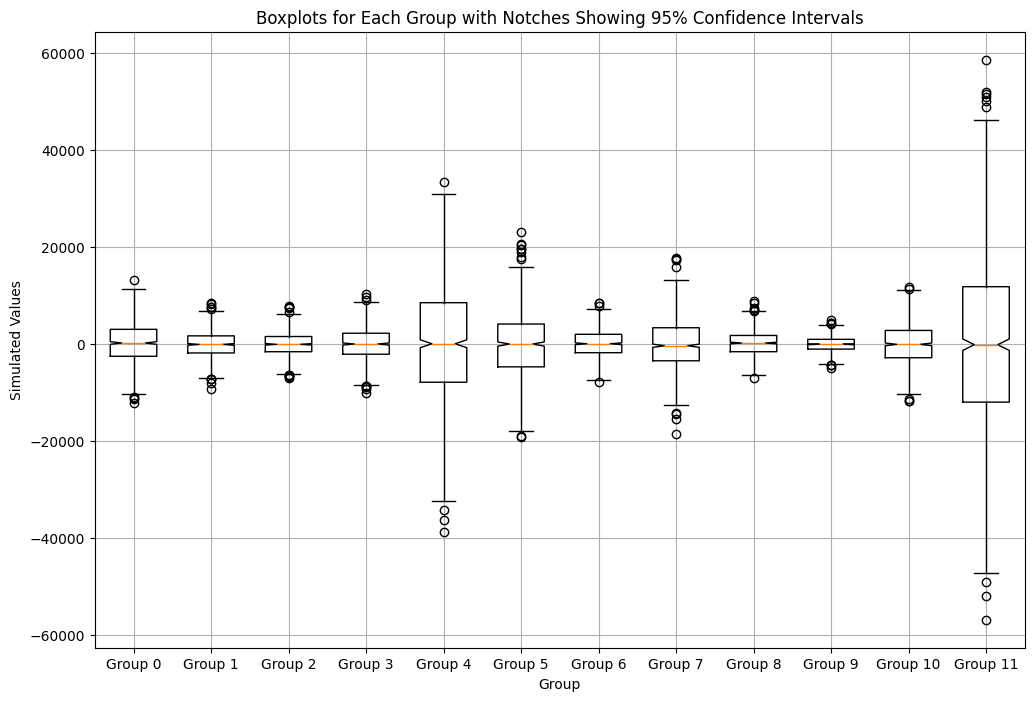

In [67]:
data = {'group': [], 'count': [], 'mu': [], 'var': []}
with open('summary_large.txt', 'r') as f:
    for line in f:
        data['group'].append(int(line.split()[0][1:][:-1]))
        data['count'].append(int(line.split()[1][1:][:-1]))
        data['mu'].append(float(line.split()[2][:-1]))
        data['var'].append(float(line.split()[3][:-1]))
        
df = pd.DataFrame(data).sort_values(by = 'group').reset_index(drop = True)

# Simulating data for each group based on mean and standard deviation
simulated_data = [np.random.normal(loc = mu, 
                                   scale = np.sqrt(var), 
                                   size = 1000) for mu, var in zip(df['mu'], df['var'])]

# Plotting
fig, ax = plt.subplots(figsize = (12, 8))

# Create a boxplot for each group
positions = range(len(df))
ax.boxplot(simulated_data, 
           positions = positions, 
           notch = True, 
           widths = 0.6)

# Labeling
ax.set_xticks(positions)
ax.set_xticklabels([f'Group {g}' for g in df['group']])
ax.set_xlabel('Group')
ax.set_ylabel('Simulated Values')
ax.set_title('Boxplots for Each Group with Notches Showing 95% Confidence Intervals')

plt.grid(True)

plt.savefig('populations.pdf')
plt.show()